## Build Quantum Fourier Transform(QFT) and Inverse QFT circuits in QpiAI Explorer Lab on Amazon Braket

In [1]:
#Install Amazon braket

%pip install amazon-braket-sdk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 313.7/313.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.0/224.0 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.7/191.7 kB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.2/139.2 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 539.8/539.8 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 10.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 4.2 MB/s eta 0:00:00
  Created wheel for antlr4-python3-runtime: filename=antlr4_python3_runtime-4.9.2-py3-none-any.whl size=144548 sha256=3ecce7a982c73eaf74293ab

In [2]:
# Creating general imports:

import numpy as np
import matplotlib.pyplot as plt

# Creating AWS imports:

from braket.circuits import Circuit, Gate
from braket.devices import LocalSimulator

In [3]:
# Invoking the Local Simulator

device = LocalSimulator()

### Implementation of QFT and inverse-QFT Circuits

In this tutorial we provide simple helper functions to implement the circuits for both QFT and inverse QFT. Remember that quantum Fourier Transform transforms a quantum state as following $|X\rangle \rightarrow |Y\rangle$, where $|X\rangle=\sum_{j=0}^{N-1}x_j|j\rangle$ and $|Y\rangle=\sum_{k=0}^{N-1}y_k|k\rangle$ such that the coefficients $y_k$ are related to $x_j$ as following
$$y_k=\frac{1}{\sqrt{N}}\sum_{j=0}^{N-1}x_j\omega^{jk}_N,$$
where $ \omega^{jk}_N=e^{2\pi i\frac{jk}{N}}.$ The implementation of this operation and its inverse are implemented below.

In [4]:
def qft(qubits):
    """
    This method constructs a circuit object corresponding to the Quantum Fourier Transform (QFT)
    algorithm which is then applied to the argument qubits.

    Args:
        qubits (int): The list of qubits on which to apply the QFT
    """
    circ = Circuit()

    # get the number of qubits
    num_qubits = len(qubits)

    for k in range(num_qubits):
        # Apply Hadamard gate on all qubits
        circ.h(qubits[k])

        # Then apply the controlled rotations gates, with weights (angles) defined by the distance to the control qubit.
        # Start on the qubit after qubit k, and iterate until the end.  When num_qubits==1, this loop does not run.
        for j in range(1,num_qubits - k):
            angle = 2*np.pi/(2**(j+1))
            circ.cphaseshift(qubits[k+j],qubits[k], angle)

    # Then add SWAP gates to reverse the order of the qubits:
    for i in range(int(np.floor(num_qubits/2))):
        circ.swap(qubits[i], qubits[-i-1])

    return circ

In [5]:
def inverse_qft(qubits):
    """
    Construct a circuit object corresponding to the inverse Quantum Fourier Transform (QFT)
    algorithm, applied to the argument qubits.  Does not use recursion to generate the circuit.

    Args:
        qubits (int): The list of qubits on which to apply the inverse QFT
    """
    # instantiate circuit object
    circ = Circuit()

    # get number of qubits
    num_qubits = len(qubits)

    # First add SWAP gates to reverse the order of the qubits:
    for i in range(int(np.floor(num_qubits/2))):
        circ.swap(qubits[i], qubits[-i-1])

    # Start on the last qubit and work to the first.
    for k in reversed(range(num_qubits)):

        # Apply the controlled rotations, with weights (angles) defined by the distance to the control qubit.
        # These angles are the negative of the angle used in the QFT.
        # Start on the last qubit and iterate until the qubit after k.
        # When num_qubits==1, this loop does not run.
        for j in reversed(range(1, num_qubits - k)):
            angle = -2*np.pi/(2**(j+1))
            circ.cphaseshift(qubits[k+j],qubits[k], angle)

        # Then add a Hadamard gate
        circ.h(qubits[k])

    return circ

### Visualization of the QFT Circuit

In order to check our implementation of the (inverse) QFT circuit, let us visualize them for small numbers of qubits. By inspection, we can see that the QFT and inverse-QFT circuits will effectively cancel each other, as desired.


### 2 Qubits:

In [6]:
# QFT example circuit
num_qubits = 2
qubits = range(num_qubits)
my_qft_circ = qft(qubits)
print('QFT CIRCUIT:')
print(my_qft_circ)

# inverse QFT example circuit
print('')
print('INVERSE-QFT CIRCUIT:')
my_iqft_circ = inverse_qft(qubits)
print(my_iqft_circ)

QFT CIRCUIT:
T  : │  0  │       1       │  2  │   3    │
      ┌───┐ ┌─────────────┐                
q0 : ─┤ H ├─┤ PHASE(1.57) ├──────────x─────
      └───┘ └──────┬──────┘          │     
                   │        ┌───┐    │     
q1 : ──────────────●────────┤ H ├────x─────
                            └───┘          
T  : │  0  │       1       │  2  │   3    │

INVERSE-QFT CIRCUIT:
T  : │   0    │  1  │       2        │  3  │
                     ┌──────────────┐ ┌───┐ 
q0 : ────x───────────┤ PHASE(-1.57) ├─┤ H ├─
         │           └──────┬───────┘ └───┘ 
         │     ┌───┐        │               
q1 : ────x─────┤ H ├────────●───────────────
               └───┘                        
T  : │   0    │  1  │       2        │  3  │


### Numerical Test Experiments

In the following we will verify that our QFT implementation works as expected with a few test examples:

1. First, we will apply the QFT algorithm to the input state $|0 0 0\rangle$ . Here, we expect a uniform superposition of all basis vectors as output, as discussed above.
2. Second, following our theoretical discussion above, we will apply the inverse QFT to a particular input state for which we expect a simple computational basis state as output.
3. Finally, we verify that the QFT and inverse-QFT circuits cancel each other, effectively yielding the identity gate.

**Example 1:**

First, let us apply the QFT algorithm to the input state $|000\rangle$. Here, we expect a uniform superposition of all basis vectors as output, as discussed above.

Exact statevector:
 [(0.354+0j), (0.354+0j), (0.354+0j), (0.354+0j), (0.354+0j), (0.354+0j), (0.354+0j), (0.354+0j)]


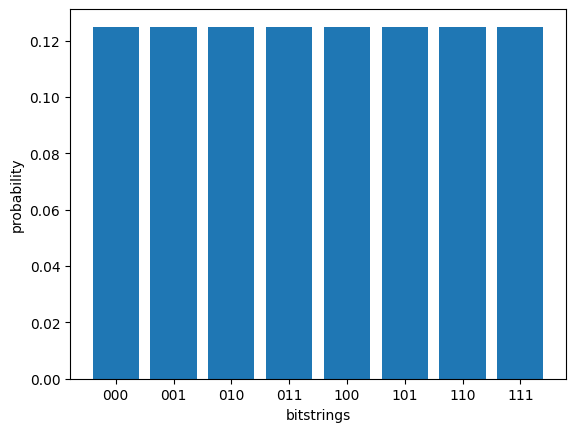

In [7]:
# check output for input |0,0,0> -> expect uniform distribution
num_qubits = 3
qubits=range(num_qubits)
my_qft_circ = qft(qubits)

# specify desired results_types
my_qft_circ.state_vector()
my_qft_circ.probability()

# Run the QFT on 3 qubits with all zeros input
task = device.run(my_qft_circ, shots=0)
result = task.result()
state_vector = result.values[0]
probs_values = result.values[1]

# format statevector for output
state_vec_pretty = np.round(state_vector, decimals=3)
state_vec_pretty = [ampl if np.abs(ampl)>10**(-5) else 0 for ampl in state_vec_pretty]

# bitstrings
format_bitstring = '{0:0' + str(num_qubits) + 'b}'
bitstring_keys = [format_bitstring.format(ii) for ii in range(2**num_qubits)]

# Print the output state vector
print('Exact statevector:\n', state_vec_pretty)

# plot probabalities
plt.bar(bitstring_keys, probs_values);
plt.xlabel('bitstrings');
plt.ylabel('probability');

Indeed, we do recover a uniform superposition of all basis vectors as output, as expected from our analysis above.

**Example 2:**

Following our theoretical discussion above, we will apply the inverse QFT to a particular input state for which we expect a simple computational basis state as output.

In [8]:
# prepare initial state
num_qubits = 3
qubits=range(num_qubits)
circ = Circuit()
circ.h(qubits)
for ii in range(num_qubits - 1):
    circ.rz(ii+1, np.pi/(2**ii))

print('1. Printing circuit for state preparation:')
print(circ)

# add inverse-QFT circuit
circ.add_circuit(inverse_qft(qubits))

# print circuit including inverse QFT
print('')
print('2. Full circuit including inverse QFT:')
print(circ)

1. Printing circuit for state preparation:
T  : │  0  │     1      │
      ┌───┐              
q0 : ─┤ H ├──────────────
      └───┘              
      ┌───┐ ┌──────────┐ 
q1 : ─┤ H ├─┤ Rz(3.14) ├─
      └───┘ └──────────┘ 
      ┌───┐ ┌──────────┐ 
q2 : ─┤ H ├─┤ Rz(1.57) ├─
      └───┘ └──────────┘ 
T  : │  0  │     1      │

2. Full circuit including inverse QFT:
T  : │  0  │     1      │   2    │  3  │       4        │          5           │       6        │  7  │
      ┌───┐                                                    ┌──────────────┐ ┌──────────────┐ ┌───┐ 
q0 : ─┤ H ├─────────────────x──────────────────────────────────┤ PHASE(-0.79) ├─┤ PHASE(-1.57) ├─┤ H ├─
      └───┘                 │                                  └──────┬───────┘ └──────┬───────┘ └───┘ 
      ┌───┐ ┌──────────┐    │           ┌──────────────┐ ┌───┐        │                │               
q1 : ─┤ H ├─┤ Rz(3.14) ├────┼───────────┤ PHASE(-1.57) ├─┤ H ├────────┼────────────────●───────────────
      └

Exact statevector:
 [0, 0, (-0.707-0.707j), 0, 0, 0, 0, 0]


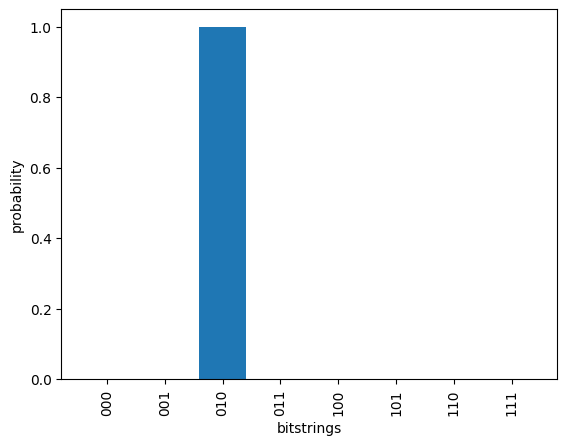

In [9]:
# specify desired results_types
circ.state_vector()
circ.probability()

# Run the QFT on 3 circuits with all zeros input
task = device.run(circ, shots=0)
result = task.result()
state_vector = result.values[0]
probs_values = result.values[1]

# format statevector for output
state_vec_pretty = np.round(state_vector, decimals=3)
state_vec_pretty = [ampl if np.abs(ampl)>10**(-5) else 0 for ampl in state_vec_pretty]

# bitstrings
format_bitstring = '{0:0' + str(num_qubits) + 'b}'
bitstring_keys = [format_bitstring.format(ii) for ii in range(2**num_qubits)]

# Print the output state vector
print('Exact statevector:\n', state_vec_pretty)

# plot probabalities
plt.bar(bitstring_keys, probs_values);
plt.xlabel('bitstrings');
plt.ylabel('probability');
plt.xticks(rotation=90);

As expected, all measurements show a unique bitstring corresponding to the integer number set with our initial state preparation, as expected. Next, let us verify that this works independent of the number of qubits.

1. Printing circuit for state preparation:
T  : │  0  │     1      │
      ┌───┐              
q0 : ─┤ H ├──────────────
      └───┘              
      ┌───┐ ┌──────────┐ 
q1 : ─┤ H ├─┤ Rz(3.14) ├─
      └───┘ └──────────┘ 
      ┌───┐ ┌──────────┐ 
q2 : ─┤ H ├─┤ Rz(1.57) ├─
      └───┘ └──────────┘ 
      ┌───┐ ┌──────────┐ 
q3 : ─┤ H ├─┤ Rz(0.79) ├─
      └───┘ └──────────┘ 
T  : │  0  │     1      │

2. Full circuit including inverse QFT:
T  : │  0  │     1      │        2        │  3  │       4        │          5           │                6                │          7           │       8        │  9  │
      ┌───┐                                                                                               ┌──────────────┐       ┌──────────────┐ ┌──────────────┐ ┌───┐ 
q0 : ─┤ H ├─────────────────x─────────────────────────────────────────────────────────────────────────────┤ PHASE(-0.39) ├───────┤ PHASE(-0.79) ├─┤ PHASE(-1.57) ├─┤ H ├─
      └───┘                 │              

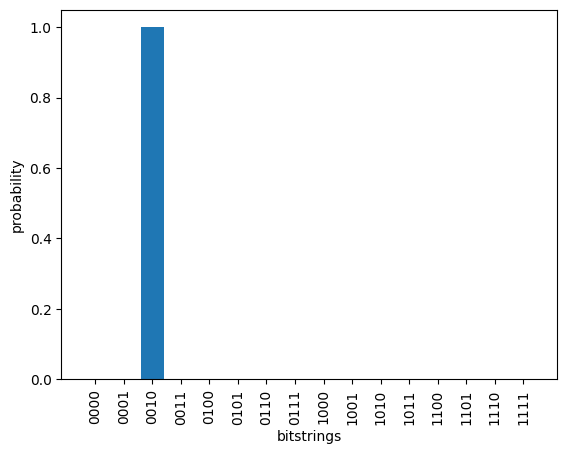

In [10]:
# prepare initial state
num_qubits = 4
qubits=range(num_qubits)
circ = Circuit()
circ.h(qubits)
for ii in range(num_qubits - 1):
    circ.rz(ii+1, np.pi/(2**ii))

print('1. Printing circuit for state preparation:')
print(circ)

# add inverse QFT circuit
circ.add_circuit(inverse_qft(qubits))

# print circuit including inverse QFT
print('')
print('2. Full circuit including inverse QFT:')
print(circ)

# specify desired results_types
circ.state_vector()
circ.probability()

# Run the QFT on 3 circuits with all zeros input
task = device.run(circ, shots=0)
result = task.result()
state_vector = result.values[0]
probs_values = result.values[1]

# format statevector for output
state_vec_pretty = np.round(state_vector, decimals=3)
state_vec_pretty = [ampl if np.abs(ampl)>10**(-5) else 0 for ampl in state_vec_pretty]

# bitstrings
format_bitstring = '{0:0' + str(num_qubits) + 'b}'
bitstring_keys = [format_bitstring.format(ii) for ii in range(2**num_qubits)]

# Print the output state vector
print('Exact statevector:\n', state_vec_pretty)

# plot probabalities
plt.bar(bitstring_keys, probs_values);
plt.xlabel('bitstrings');
plt.ylabel('probability');
plt.xticks(rotation=90);

Example 3:

In this section, we verify that the $QFT$ and $QFT\dagger$ circuits cancel each other, effectively yielding the identity gate $I$.

Exact statevector:
 [(1+0j), 0, 0, 0, 0, 0, 0, 0]


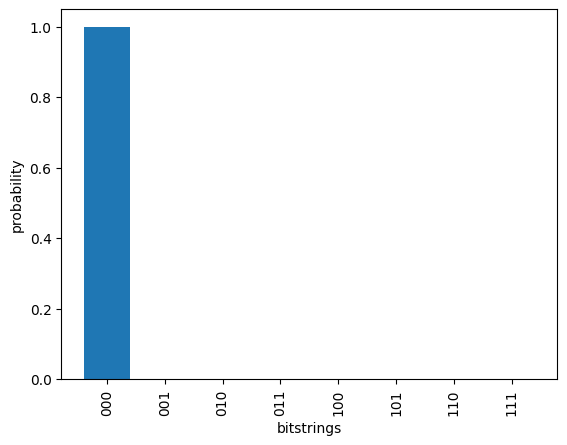

In [11]:
# prepare initial state
num_qubits = 3
qubits=range(num_qubits)
circ = Circuit()

# add QFT and inverse-QFT circuits
circ.add_circuit(qft(qubits))
circ.add_circuit(inverse_qft(qubits))

# specify desired results_types
circ.state_vector()
circ.probability()

# Run the QFT on 3 circuits with all zeros input
task = device.run(circ, shots=0)
result = task.result()
state_vector = result.values[0]
probs_values = result.values[1]

# format statevector for output
state_vec_pretty = np.round(state_vector, decimals=3)
state_vec_pretty = [ampl if np.abs(ampl)>10**(-5) else 0 for ampl in state_vec_pretty]

# bitstrings
format_bitstring = '{0:0' + str(num_qubits) + 'b}'
bitstring_keys = [format_bitstring.format(ii) for ii in range(2**num_qubits)]

# Print the output state vector
print('Exact statevector:\n', state_vec_pretty)

# plot probabalities
plt.bar(bitstring_keys, probs_values);
plt.xlabel('bitstrings');
plt.ylabel('probability');
plt.xticks(rotation=90);

Next we will check the same with input state $|101\rangle$.

Exact statevector:
 [0, 0, 0, 0, 0, (1+0j), 0, 0]


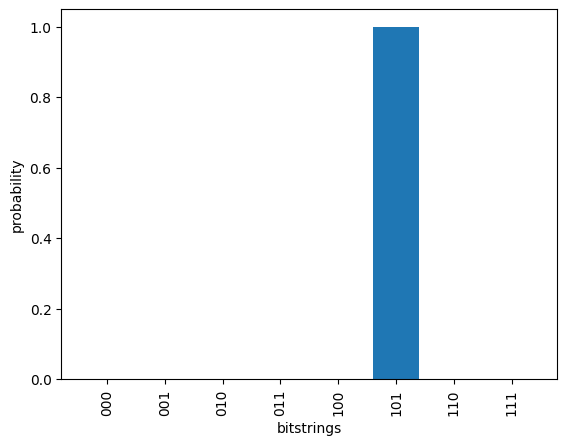

In [12]:
# prepare initial state
num_qubits = 3
qubits=range(num_qubits)
circ = Circuit()
circ.x(0)
circ.x(2)

# add QFT circuit

circ.add_circuit(qft(qubits))
circ.add_circuit(inverse_qft(qubits))

# specify desired results_types
circ.state_vector()
circ.probability()

# Run the QFT on 3 circuits with all zeros input
task = device.run(circ, shots=0)
result = task.result()
state_vector = result.values[0]
probs_values = result.values[1]

# format statevector for output
state_vec_pretty = np.round(state_vector, decimals=3)
state_vec_pretty = [ampl if np.abs(ampl)>10**(-5) else 0 for ampl in state_vec_pretty]

# bitstrings
format_bitstring = '{0:0' + str(num_qubits) + 'b}'
bitstring_keys = [format_bitstring.format(ii) for ii in range(2**num_qubits)]

# Print the output state vector
print('Exact statevector:\n', state_vec_pretty)

# plot probabalities
plt.bar(bitstring_keys, probs_values);
plt.xlabel('bitstrings');
plt.ylabel('probability');
plt.xticks(rotation=90);